### **1. Membuat Dataset Sintetis Mirip Data Pasar Ikan**

Berdasarkan deskripsi Anda, saya akan membuat dataset sintetis dengan 159 sampel dan 7 atribut. 'Berat' akan menjadi variabel target, dan 'Panjang', 'Tinggi', serta 'Lebar' akan menjadi fitur utama untuk memprediksinya.

In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 159

# Generate synthetic features
panjang = np.random.uniform(10, 60, n_samples)  # Length in cm
tinggi = np.random.uniform(5, 20, n_samples)    # Height in cm
lebar = np.random.uniform(2, 15, n_samples)     # Width in cm

# Let's add 3 more 'other' numerical attributes to reach 7 attributes as described
other_feature_1 = np.random.uniform(1, 10, n_samples)
other_feature_2 = np.random.normal(50, 10, n_samples)
other_feature_3 = np.random.randint(0, 5, n_samples)

# Generate 'berat' (weight) with a linear relationship to features and some noise
# Formula: berat = (panjang * 10) + (tinggi * 15) + (lebar * 20) + bias + noise
berat = (panjang * 10) + (tinggi * 15) + (lebar * 20) + 50 + np.random.normal(0, 50, n_samples)

# Ensure weight is positive
berat[berat < 0] = 1 # Replace negative weights with a small positive value

# Create DataFrame
df = pd.DataFrame({
    'Panjang': panjang,
    'Tinggi': tinggi,
    'Lebar': lebar,
    'Other_Feature_1': other_feature_1,
    'Other_Feature_2': other_feature_2,
    'Other_Feature_3': other_feature_3,
    'Berat': berat
})

print("Dataset sintetis berhasil dibuat:")

Dataset sintetis berhasil dibuat:


In [2]:
display(df.head())

,Panjang,Tinggi,Lebar,Other_Feature_1,Other_Feature_2,Other_Feature_3,Berat
0,28.727006,15.923245,4.033682,5.984689,33.935537,2,740.243445
1,57.535715,10.516747,5.253158,9.723723,52.034636,2,876.921216
2,46.599697,14.484587,9.139947,5.707881,42.436493,3,976.444324
3,39.932924,14.502946,11.289747,6.664588,35.777463,2,904.192728
4,17.800932,13.036620,10.582566,7.261738,43.534271,2,656.825379


In [3]:
print(df.info())
print("\nStatistik Deskriptif:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Panjang          159 non-null    float64
 1   Tinggi           159 non-null    float64
 2   Lebar            159 non-null    float64
 3   Other_Feature_1  159 non-null    float64
 4   Other_Feature_2  159 non-null    float64
 5   Other_Feature_3  159 non-null    int64  
 6   Berat            159 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 8.8 KB
None

Statistik Deskriptif:


,Panjang,Tinggi,Lebar,Other_Feature_1,Other_Feature_2,Other_Feature_3,Berat
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,33.778096,12.729715,8.430105,5.576573,49.339365,1.949686,749.430947
std,14.855301,4.366753,4.023830,2.636304,9.847048,1.435529,182.754631
min,10.276106,5.075924,2.140889,1.130902,25.283555,0.000000,375.745270
25%,21.251074,9.020260,4.425999,3.249033,42.063151,1.000000,638.077306
50%,32.803499,13.231007,8.427464,5.605097,49.497619,2.000000,740.150677
75%,47.908405,16.154450,11.830528,7.858561,55.667840,3.000000,900.001414
max,59.344347,19.850808,14.908542,9.997459,74.457520,4.000000,1206.609062


### **2. Implementasi Regresi Linear dengan scikit-learn**

Sekarang kita akan menerapkan model Regresi Linear menggunakan dataset sintetis yang telah dibuat. Kita akan membagi data menjadi set pelatihan dan pengujian, melatih model, dan mengevaluasi kinerjanya.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Definisikan fitur (X) dan target (y)
X = df[['Panjang', 'Tinggi', 'Lebar', 'Other_Feature_1', 'Other_Feature_2', 'Other_Feature_3']]
y = df['Berat']

# Bagi data menjadi set pelatihan dan pengujian (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran data pelatihan (X_train): {X_train.shape}")
print(f"Ukuran data pengujian (X_test): {X_test.shape}")

Ukuran data pelatihan (X_train): (127, 6)
Ukuran data pengujian (X_test): (32, 6)


In [5]:
# Inisialisasi model Regresi Linear
model = LinearRegression()

# Latih model menggunakan data pelatihan
model.fit(X_train, y_train)

# Lakukan prediksi pada data pengujian
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Hasil Model Regresi Linear ---")
print(f"Koefisien (Coefficients): {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


--- Hasil Model Regresi Linear ---
Koefisien (Coefficients): [ 9.96039447 15.27522019 19.27225969  1.66746168 -0.18094101  2.82408632]
Intercept: 52.4319457578124
Mean Squared Error (MSE): 2103.56
R-squared (R2): 0.94


### **3. Visualisasi Hasil Regresi Linear**

Kita akan memvisualisasikan hasil prediksi dibandingkan dengan nilai aktual untuk memahami seberapa baik model bekerja.

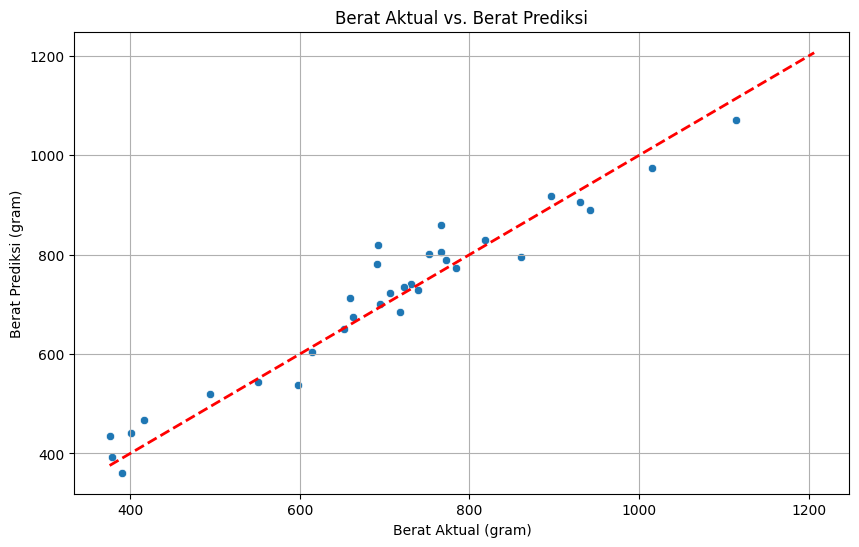

In [6]:
# Visualisasi: Prediksi vs. Nilai Aktual
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Garis y=x sempurna
plt.xlabel("Berat Aktual (gram)")
plt.ylabel("Berat Prediksi (gram)")
plt.title("Berat Aktual vs. Berat Prediksi")
plt.grid(True)
plt.show()

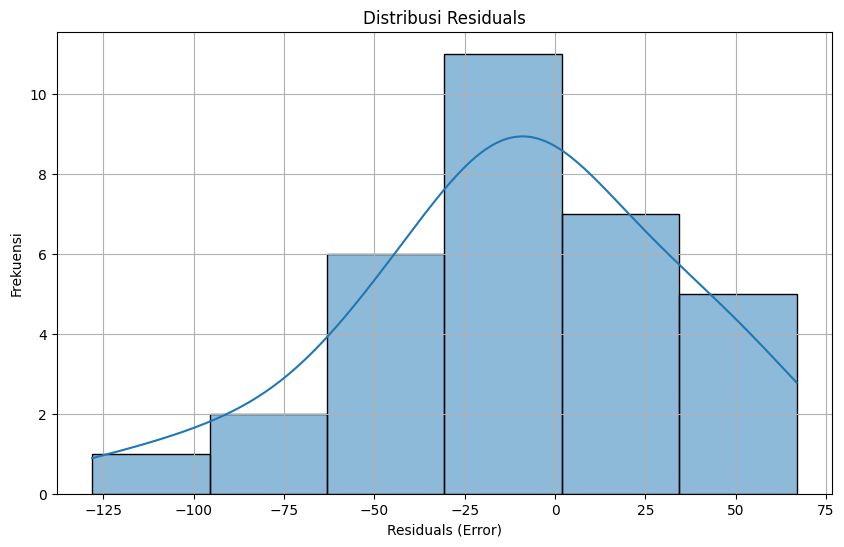

In [7]:
# Visualisasi Residuals (Error)
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals (Error)")
plt.ylabel("Frekuensi")
plt.title("Distribusi Residuals")
plt.grid(True)
plt.show()

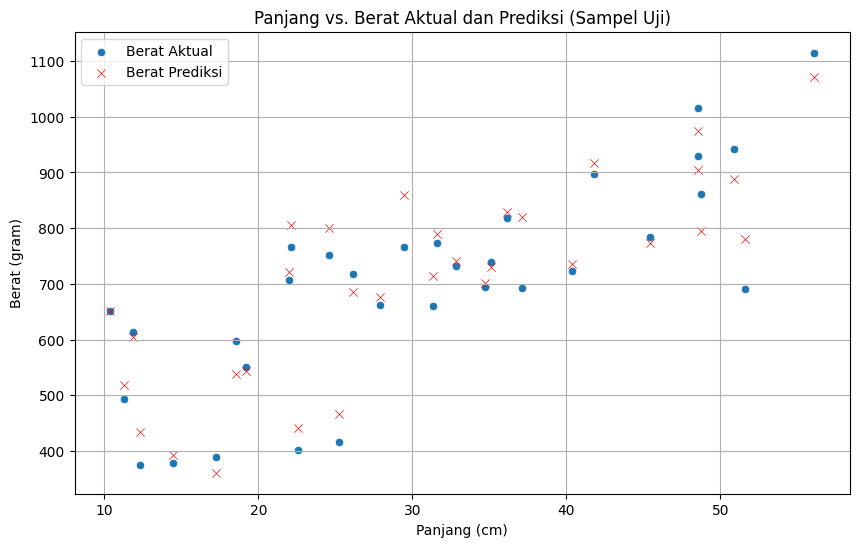

In [8]:
# Visualisasi: Contoh satu fitur (Panjang) terhadap Berat (dengan garis regresi)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Panjang'], y=y_test, label='Berat Aktual')
sns.scatterplot(x=X_test['Panjang'], y=y_pred, color='red', marker='x', label='Berat Prediksi')

# Untuk memvisualisasikan garis regresi dari model untuk fitur 'Panjang'
# Ini bukan visualisasi murni 2D dari model multivariat, tetapi representasi sederhana
# Perlu diperhatikan bahwa ini mengabaikan kontribusi fitur lain.
# Lebih baik menggunakan plot aktual vs prediksi di atas.

# Namun, jika ingin menunjukkan tren umum:
# plt.plot(X_test['Panjang'], y_pred, 'g--')

plt.xlabel("Panjang (cm)")
plt.ylabel("Berat (gram)")
plt.title("Panjang vs. Berat Aktual dan Prediksi (Sampel Uji)")
plt.legend()
plt.grid(True)
plt.show()